# Прогнозирование цен акций через `auto_arima`

Этот notebook сделан как более простой учебный вариант pipeline. Он ближе к теории: параметры моделей семейства ARIMA/SARIMA подбираются автоматически через `pmdarima.auto_arima`.

Важная идея:

- мы **не пишем ручной перебор** `p`, `d`, `q`, `P`, `D`, `Q`;
- `auto_arima` сама ищет подходящую модель по информационному критерию AIC;
- мы считаем метрики на тестовом отрезке, чтобы понять качество прогноза;
- финальную модель сохраняем в таком же формате, как нужно веб-приложению Streamlit.

После выполнения notebook приложение `frontend.py` продолжит работать с готовыми файлами из папки `models/`.

## 1. Импорт библиотек

Здесь нет большого количества вспомогательных функций. Код ниже специально оставлен более последовательным, чтобы его было легче читать студентам-новичкам.

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX, SARIMAXResults
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

## 2. Настройки

`SEASONAL_PERIOD = 5` означает недельную сезонность в торговых днях: в обычной биржевой неделе примерно 5 торговых дней.

Это учебная гипотеза для SARIMA/SARIMAX-подхода, а не инвестиционное утверждение о рынке.

In [2]:
PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

MODEL_DIR = PROJECT_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

TICKERS = ["AAPL", "MSFT", "NVDA"]
PERIOD = "5y"
TEST_SIZE = 90
SEASONAL_PERIOD = 5

TICKER_NAMES = {
    "AAPL": "Apple",
    "MSFT": "Microsoft",
    "NVDA": "NVIDIA",
}

print("Project dir:", PROJECT_DIR)
print("Model dir:", MODEL_DIR)

Project dir: /Users/alexandre/Documents/TimeSeries
Model dir: /Users/alexandre/Documents/TimeSeries/models


## 3. Загружаем один ряд для знакомства

Для примера посмотрим на Apple. В основном pipeline ниже те же действия будут выполнены для всех тикеров.

In [3]:
example_ticker = "AAPL"
example_data = yf.download(
    example_ticker,
    period=PERIOD,
    interval="1d",
    auto_adjust=True,
    progress=False,
    threads=False,
)

# В новых версиях yfinance иногда приходит MultiIndex: (Close, AAPL).
# Поэтому аккуратно достаем именно цену закрытия.
if isinstance(example_data.columns, pd.MultiIndex):
    example_close = example_data[("Close", example_ticker)]
else:
    example_close = example_data["Close"]

example_close = example_close.dropna().astype(float)
example_close.index = pd.to_datetime(example_close.index).tz_localize(None)
example_close = example_close.asfreq("B").ffill().dropna()
example_close.name = "close"

example_close.tail()

Date
2026-05-26    308.329987
2026-05-27    310.850006
2026-05-28    312.510010
2026-05-29    312.059998
2026-06-01    306.309998
Freq: B, Name: close, dtype: float64

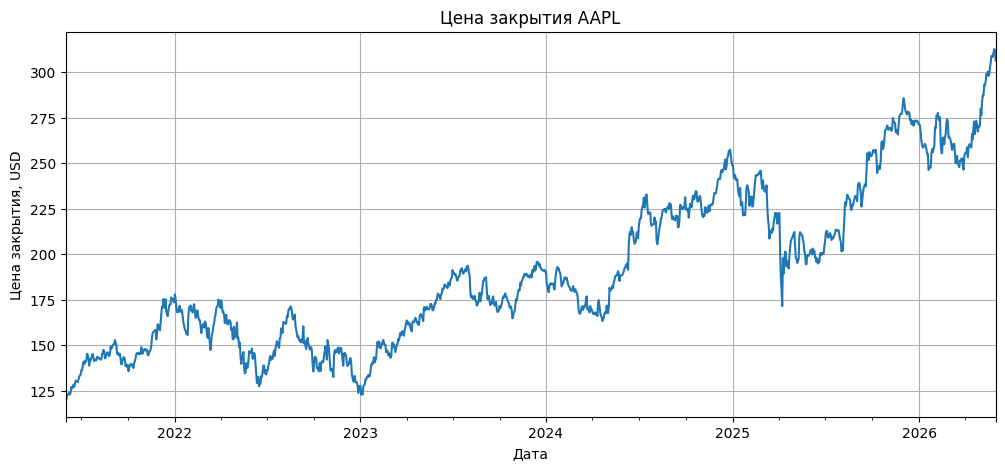

In [4]:
example_close.plot(title=f"Цена закрытия {example_ticker}")
plt.xlabel("Дата")
plt.ylabel("Цена закрытия, USD")
plt.show()

## 4. Проверка стационарности

В теории мы смотрели ADF-тест. Для цен акций исходный ряд часто нестационарен, а первая разность может быть ближе к стационарному ряду.

`auto_arima` может сама подобрать порядок дифференцирования `d` и сезонного дифференцирования `D`.

In [5]:
adf_original = adfuller(example_close.dropna())
adf_diff = adfuller(example_close.diff().dropna())

print("Исходный ряд")
print(f"ADF statistic: {adf_original[0]:.4f}")
print(f"p-value: {adf_original[1]:.4f}")
print()
print("Первая разность")
print(f"ADF statistic: {adf_diff[0]:.4f}")
print(f"p-value: {adf_diff[1]:.4f}")

Исходный ряд
ADF statistic: -0.2316
p-value: 0.9346

Первая разность
ADF statistic: -12.8357
p-value: 0.0000


## 5. Как `auto_arima` подбирает параметры

В теории использовался такой подход:

```python
from pmdarima import auto_arima

parameter_search = auto_arima(
    train,
    start_p=1,
    start_q=1,
    max_p=3,
    max_q=3,
    seasonal=True,
    m=12,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
)
```

Здесь делаем то же самое, только для дневных цен акций: используем `m=5` и явно задаем `D=1`, как в теоретическом примере с сезонным дифференцированием.

Дополнительно ставим `return_valid_fits=True`, чтобы получить не только лучшую модель, но и таблицу моделей, которые `auto_arima` реально проверила.

## 6. Основной pipeline обучения

Ниже весь процесс находится в одной большой, но последовательной ячейке:

1. загружаем данные;
2. масштабируем цены через `MinMaxScaler`;
3. делим ряд на train/test;
4. запускаем `auto_arima`;
5. считаем метрики на тесте;
6. обучаем финальную `SARIMAX` с найденными параметрами на всей истории;
7. сохраняем модель, scaler и metadata для Streamlit-приложения.

In [6]:
all_result_rows = []
summary_rows = []

for ticker in TICKERS:
    print("=" * 80)
    print(f"Тикер: {ticker}")

    data = yf.download(
        ticker,
        period=PERIOD,
        interval="1d",
        auto_adjust=True,
        progress=False,
        threads=False,
    )

    if isinstance(data.columns, pd.MultiIndex):
        close = data[("Close", ticker)]
    else:
        close = data["Close"]

    close = close.dropna().astype(float)
    close.index = pd.to_datetime(close.index).tz_localize(None)
    close = close.asfreq("B").ffill().dropna()
    close.name = "close"

    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(close.to_numpy().reshape(-1, 1)).ravel()

    train = scaled[:-TEST_SIZE]
    test = scaled[-TEST_SIZE:]
    test_prices = scaler.inverse_transform(test.reshape(-1, 1)).ravel()

    print(f"Наблюдений: {len(close)}")
    print(f"Train: {len(train)}; test: {len(test)}")

    valid_fits = auto_arima(
        train,
        start_p=0,
        start_q=0,
        max_p=3,
        max_q=3,
        start_P=0,
        start_Q=0,
        max_P=1,
        max_Q=1,
        d=None,
        D=1,
        seasonal=True,
        m=SEASONAL_PERIOD,
        trace=True,
        error_action="ignore",
        suppress_warnings=True,
        stepwise=True,
        information_criterion="aic",
        return_valid_fits=True,
    )

    if not isinstance(valid_fits, tuple):
        valid_fits = (valid_fits,)

    # При return_valid_fits=True первая модель в кортеже - лучшая по AIC.
    auto_model = valid_fits[0]
    print("Лучшая auto_arima модель:")
    print("order =", auto_model.order)
    print("seasonal_order =", auto_model.seasonal_order)

    ticker_rows = []

    for number, candidate_model in enumerate(valid_fits, start=1):
        order = candidate_model.order
        seasonal_order = candidate_model.seasonal_order
        p, d, q = order
        P, D, Q, s = seasonal_order

        if P > 0 or D > 0 or Q > 0:
            family = "SARIMAX"
        elif d > 0:
            family = "ARIMA"
        elif p > 0 and q > 0:
            family = "ARMA"
        elif p > 0:
            family = "AR"
        elif q > 0:
            family = "MA"
        else:
            family = "ARIMA"

        forecast_scaled = np.asarray(candidate_model.predict(n_periods=len(test)), dtype=float)
        forecast_prices = scaler.inverse_transform(forecast_scaled.reshape(-1, 1)).ravel()
        forecast_prices = np.maximum(forecast_prices, 0)

        mae = mean_absolute_error(test_prices, forecast_prices)
        rmse = np.sqrt(mean_squared_error(test_prices, forecast_prices))
        mape = np.mean(np.abs((test_prices - forecast_prices) / np.maximum(np.abs(test_prices), 1e-8))) * 100

        row = {
            "ticker": ticker,
            "candidate_number": number,
            "selected_by_auto_arima": number == 1,
            "family": family,
            "order": order,
            "seasonal_order": seasonal_order,
            "mae": float(mae),
            "rmse": float(rmse),
            "mape": float(mape),
            "aic": float(candidate_model.aic()),
            "bic": float(candidate_model.bic()),
        }
        ticker_rows.append(row)
        all_result_rows.append(row)

    ticker_results = pd.DataFrame(ticker_rows).sort_values("aic")
    selected = ticker_results[ticker_results["selected_by_auto_arima"]].iloc[0]
    best_by_rmse = ticker_results.sort_values("rmse").iloc[0]

    print("Метрики модели, выбранной auto_arima по AIC:")
    print(selected[["family", "order", "seasonal_order", "mae", "rmse", "mape", "aic"]])
    print()
    print("Кандидат с минимальным RMSE на тесте среди проверенных auto_arima моделей:")
    print(best_by_rmse[["family", "order", "seasonal_order", "mae", "rmse", "mape", "aic"]])

    final_model = SARIMAX(
        scaled,
        order=auto_model.order,
        seasonal_order=auto_model.seasonal_order,
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    final_result = final_model.fit(disp=False, maxiter=80)

    model_path = MODEL_DIR / f"{ticker}_model.pkl"
    scaler_path = MODEL_DIR / f"{ticker}_scaler.pkl"
    metadata_path = MODEL_DIR / f"{ticker}_metadata.json"

    final_result.save(str(model_path), remove_data=False)
    joblib.dump(scaler, scaler_path)

    metadata = {
        "ticker": ticker,
        "company": TICKER_NAMES.get(ticker, ticker),
        "family": selected["family"],
        "order": list(auto_model.order),
        "seasonal_order": list(auto_model.seasonal_order),
        "selection_method": "pmdarima.auto_arima",
        "selection_criterion": "AIC",
        "metrics": {
            "mae": float(selected["mae"]),
            "rmse": float(selected["rmse"]),
            "mape": float(selected["mape"]),
        },
        "best_test_candidate": {
            "family": best_by_rmse["family"],
            "order": list(best_by_rmse["order"]),
            "seasonal_order": list(best_by_rmse["seasonal_order"]),
            "mae": float(best_by_rmse["mae"]),
            "rmse": float(best_by_rmse["rmse"]),
            "mape": float(best_by_rmse["mape"]),
        },
        "aic": float(final_result.aic),
        "bic": float(final_result.bic),
        "history_start": str(close.index.min().date()),
        "history_end": str(close.index.max().date()),
        "test_size": TEST_SIZE,
        "seasonal_period": SEASONAL_PERIOD,
        "data_source": "Yahoo Finance",
        "model_path": model_path.name,
        "scaler_path": scaler_path.name,
    }

    metadata_path.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")
    summary_rows.append(metadata)

print("Готово")

Тикер: AAPL


Наблюдений: 1304
Train: 1214; test: 90
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,1,0)[5] intercept   : AIC=-4555.736, Time=0.09 sec


 ARIMA(1,0,0)(1,1,0)[5] intercept   : AIC=-6093.542, Time=0.54 sec


 ARIMA(0,0,1)(0,1,1)[5] intercept   : AIC=-5375.865, Time=0.69 sec
 ARIMA(0,0,0)(0,1,0)[5]             : AIC=-4551.099, Time=0.04 sec
 ARIMA(1,0,0)(0,1,0)[5] intercept   : AIC=-5820.197, Time=0.05 sec


 ARIMA(1,0,0)(1,1,1)[5] intercept   : AIC=inf, Time=1.70 sec


...

 ARIMA(3,0,2)(0,1,1)[5] intercept   : AIC=-7274.930, Time=2.03 sec


 ARIMA(2,0,0)(0,1,1)[5] intercept   : AIC=-7161.999, Time=1.57 sec


 ARIMA(2,0,2)(0,1,1)[5] intercept   : AIC=-7272.072, Time=1.92 sec


 ARIMA(3,0,1)(0,1,1)[5]             : AIC=inf, Time=0.93 sec

Best model:  ARIMA(3,0,1)(0,1,1)[5] intercept
Total fit time: 27.503 seconds
Лучшая auto_arima модель:
order = (3, 0, 1)
seasonal_order = (0, 1, 1, 5)
Метрики модели, выбранной auto_arima по AIC:
family                 SARIMAX
order                (3, 0, 1)
seasonal_order    (0, 1, 1, 5)
mae                   12.34694
rmse                 15.907074
mape                  6.132941
aic               -7284.640698
Name: 0, dtype: object

Кандидат с минимальным RMSE на тесте среди проверенных auto_arima моделей:
family                 SARIMAX
order                (3, 0, 2)
seasonal_order    (0, 1, 1, 5)
mae                  10.873979
rmse                 13.391942
mape                   5.59638
aic               -7274.929807
Name: 1, dtype: object


Готово


## 7. Таблица результатов

`selected_by_auto_arima=True` показывает модель, которую выбрала сама `auto_arima` по AIC. Для прозрачности рядом считаются тестовые метрики всех моделей, которые автонастройка реально проверила.

In [7]:
results_df = pd.DataFrame(all_result_rows)
results_path = MODEL_DIR / "auto_arima_model_results.csv"
results_df.to_csv(results_path, index=False)

summary_path = MODEL_DIR / "auto_arima_training_summary.json"
summary_path.write_text(json.dumps(summary_rows, ensure_ascii=False, indent=2), encoding="utf-8")

print("Таблица результатов:", results_path)
print("Сводка обучения:", summary_path)

results_df.head()

Таблица результатов: /Users/alexandre/Documents/TimeSeries/models/auto_arima_model_results.csv
Сводка обучения: /Users/alexandre/Documents/TimeSeries/models/auto_arima_training_summary.json


,ticker,candidate_number,selected_by_auto_arima,family,order,seasonal_order,mae,rmse,mape,aic,bic
0,AAPL,1,True,SARIMAX,"(3, 0, 0)","(1, 1, 0, 5)",19.473830,26.165325,6.820213,-6122.888833,-6097.401089
1,AAPL,2,False,SARIMAX,"(3, 0, 0)","(1, 1, 0, 5)",15.851919,21.589924,5.552709,-6122.385512,-6091.800219
2,AAPL,3,False,SARIMAX,"(3, 0, 1)","(1, 1, 0, 5)",19.852086,26.506257,6.957769,-6116.683754,-6086.098461
3,AAPL,4,False,SARIMAX,"(3, 0, 1)","(1, 1, 0, 5)",16.152527,21.932886,5.658507,-6116.038338,-6080.355496
4,AAPL,5,False,SARIMAX,"(2, 0, 0)","(1, 1, 0, 5)",20.445147,27.037281,7.174004,-6107.026472,-6086.636277


In [8]:
selected_models = results_df[results_df["selected_by_auto_arima"]].copy()
selected_models[["ticker", "family", "order", "seasonal_order", "mae", "rmse", "mape", "aic", "bic"]]

,ticker,family,order,seasonal_order,mae,rmse,mape,aic,bic
0,AAPL,SARIMAX,"(3, 0, 0)","(1, 1, 0, 5)",19.473830,26.165325,6.820213,-6122.888833,-6097.401089
16,MSFT,SARIMAX,"(3, 0, 0)","(1, 1, 0, 5)",55.650599,59.573466,14.074132,-6170.185822,-6144.698078
33,NVDA,SARIMAX,"(3, 0, 1)","(0, 1, 1, 5)",12.346940,15.907074,6.132941,-7284.640698,-7248.957856


In [9]:
best_test_models = (
    results_df
    .sort_values(["ticker", "rmse", "mape"])
    .groupby("ticker")
    .head(1)
)
best_test_models[["ticker", "family", "order", "seasonal_order", "mae", "rmse", "mape", "aic", "bic"]]

,ticker,family,order,seasonal_order,mae,rmse,mape,aic,bic
7,AAPL,SARIMAX,"(2, 0, 1)","(1, 1, 0, 5)",13.939822,17.081523,5.139895,-5986.854624,-5956.269331
32,MSFT,SARIMAX,"(0, 0, 0)","(0, 1, 0, 5)",52.044880,56.426825,13.165457,-4759.065300,-4753.967751
34,NVDA,SARIMAX,"(3, 0, 2)","(0, 1, 1, 5)",10.873979,13.391942,5.596380,-7274.929807,-7234.149416


In [10]:
family_comparison = (
    results_df
    .groupby("family")[["mae", "rmse", "mape", "aic", "bic"]]
    .mean()
    .sort_values("rmse")
)
family_comparison

,mae,rmse,mape,aic,bic
family,,,,,
SARIMAX,30.786545,34.864959,9.349046,-6057.228434,-6034.289464


## 8. Проверка сохраненных артефактов

Загрузим одну сохраненную модель и scaler. Это имитирует то, что делает Streamlit-приложение: модель не обучается заново, а только строит прогноз.

In [11]:
check_ticker = TICKERS[0]
loaded_model = SARIMAXResults.load(MODEL_DIR / f"{check_ticker}_model.pkl")
loaded_scaler = joblib.load(MODEL_DIR / f"{check_ticker}_scaler.pkl")
loaded_metadata = json.loads((MODEL_DIR / f"{check_ticker}_metadata.json").read_text(encoding="utf-8"))

fresh_data = yf.download(
    check_ticker,
    period="2y",
    interval="1d",
    auto_adjust=True,
    progress=False,
    threads=False,
)

if isinstance(fresh_data.columns, pd.MultiIndex):
    fresh_close = fresh_data[("Close", check_ticker)]
else:
    fresh_close = fresh_data["Close"]

fresh_close = fresh_close.dropna().astype(float)
fresh_close.index = pd.to_datetime(fresh_close.index).tz_localize(None)
fresh_close = fresh_close.asfreq("B").ffill().dropna()

fresh_scaled = loaded_scaler.transform(fresh_close.to_numpy().reshape(-1, 1)).ravel()
actualized_model = loaded_model.apply(fresh_scaled, refit=False)
forecast_scaled = np.asarray(actualized_model.forecast(steps=10), dtype=float)
forecast_prices = loaded_scaler.inverse_transform(forecast_scaled.reshape(-1, 1)).ravel()

print(loaded_metadata)
print(np.round(forecast_prices, 2))

{'ticker': 'AAPL', 'company': 'Apple', 'family': 'SARIMAX', 'order': [3, 0, 0], 'seasonal_order': [1, 1, 0, 5], 'selection_method': 'pmdarima.auto_arima', 'selection_criterion': 'AIC', 'metrics': {'mae': 19.473830082190826, 'rmse': 26.165325089105973, 'mape': 6.820213124740214}, 'best_test_candidate': {'family': 'SARIMAX', 'order': [2, 0, 1], 'seasonal_order': [1, 1, 0, 5], 'mae': 13.939822154536092, 'rmse': 17.081523214359386, 'mape': 5.139895158853136}, 'aic': -6502.2194101702335, 'bic': -6471.240375825154, 'history_start': '2021-06-02', 'history_end': '2026-06-01', 'test_size': 90, 'seasonal_period': 5, 'data_source': 'Yahoo Finance', 'model_path': 'AAPL_model.pkl', 'scaler_path': 'AAPL_scaler.pkl'}
[305.38 307.5  309.5  310.96 307.88 307.25 309.64 311.57 312.24 308.02]


## Итог

Этот notebook делает то же, что нужно для проекта, но ближе к теории:

- параметры подбирает `auto_arima`;
- результаты проверенных моделей сохраняются в `models/auto_arima_model_results.csv`;
- для каждого тикера сохраняются `model.pkl`, `scaler.pkl`, `metadata.json`;
- Streamlit-приложение запускается той же командой:

```bash
streamlit run frontend.py
```

Прогноз цен акций используется только как учебный пример временных рядов, а не как финансовая рекомендация.